In [22]:
import os

os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import emcee
from seaborn import kdeplot

In [78]:
a = 2
b = 0.1
sigma_x = 1

def log_dens(u):
    y = cond_var
    scale = 1 / (2 * sigma_x**2)
    sum_part = (a * (y + b * (u**2 + a**2))) ** 2 + (u**2) / (a**2)
    return -scale * sum_part

In [104]:
np.random.seed(39)
initial = np.random.randn(4, 1)
nwalkers, ndim = initial.shape
nsteps = 4 ** 4

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_dens)
sampler.run_mcmc(initial, nsteps, progress=True);

100%|██████████| 256/256 [00:00<00:00, 7090.54it/s]


In [105]:
np.vstack(sampler.chain)

array([[ 2.07344018],
       [ 3.50404291],
       [ 3.65162612],
       ...,
       [-6.21732825],
       [-6.21732825],
       [-6.21732825]], shape=(1024, 1))

<Axes: ylabel='Density'>

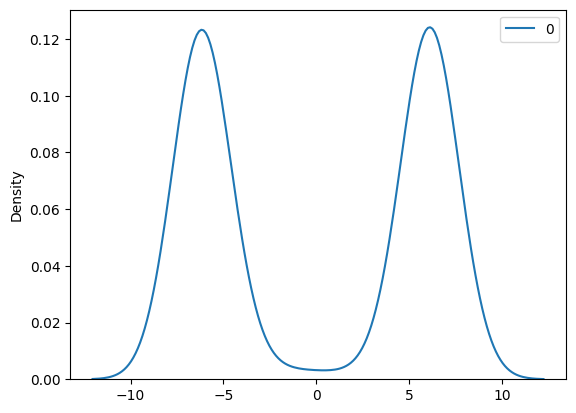

In [106]:
kdeplot(np.vstack(sampler.chain))

In [75]:
mcmc_samps = np.load("mcmc_results/mcmc_results_5/mcmc_samps_65536_1.npy")
cond_var = np.load("mcmc_results/mcmc_results_5/cond_vars_1.npy")

<Axes: ylabel='Density'>

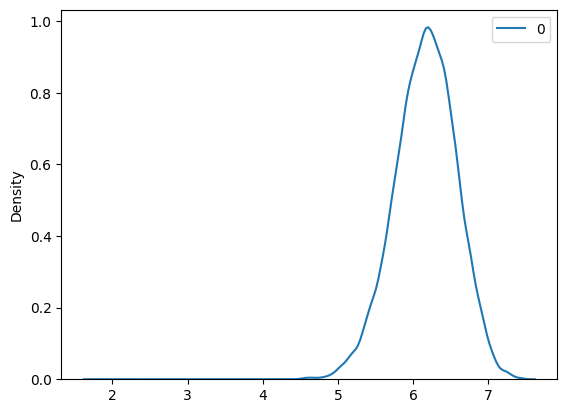

In [74]:
kdeplot(mcmc_samps)

In [82]:
cond_var

array([-4.55791761])